# Experiment Prioritization Simulator (GenAI + Quant) — Notebook

Este notebook te dá um **framework completo** para:
- Priorizar experimentos (Impacto × Risco × Esforço × Aprendizado)
- Rodar **simulações Monte Carlo** (distribuições realistas)
- Fazer **análise de sensibilidade** (o que mais importa)
- Gerar **gráficos** e um ranking final
- (Opcional) Rodar **análise causal** com `dowhy` em dados históricos

> **Importante:** o modelo não “adivinha” o futuro. Ele te ajuda a **quantificar incerteza** e tomar decisão com menos achismo.


In [3]:
!pip -q install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# Se estiver rodando em ambiente novo:
# !pip -q install numpy pandas matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict

np.random.seed(42)


## 1) Helpers: distribuições e amostragem

- **Beta**: probabilidades (adoção, taxa de evento ruim)
- **Normal truncada**: lifts (evita valores absurdos)
- **Lognormal**: valores sempre positivos (R$ por evento, custos)


In [5]:
import math

def clip(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)

def beta_from_mean_concentration(mean: float, concentration: float):
    a = mean * concentration
    b = (1 - mean) * concentration
    return a, b

def sample_beta(mean, concentration, n):
    a, b = beta_from_mean_concentration(mean, concentration)
    return np.random.beta(a, b, size=n)

def sample_trunc_normal(mu, sigma, n, lo=-np.inf, hi=np.inf):
    x = np.random.normal(mu, sigma, size=n)
    return clip(x, lo, hi)

def sample_lognormal_from_mean_cv(mean, cv, n):
    sigma2 = math.log(1 + cv**2)
    sigma = math.sqrt(sigma2)
    mu = math.log(mean) - 0.5 * sigma2
    return np.random.lognormal(mu, sigma, size=n)


## 2) Especificação do experimento

Cada experimento vira um objeto com:
- escala (usuários elegíveis)
- adoção (probabilidade)
- lift (efeito incremental)
- valor (R$ por evento incremental)
- custos (fixo + variável)
- downside (probabilidade e custo do evento ruim)
- scores de esforço, risco e aprendizado (0..10 / 0..1)


In [7]:
@dataclass
class ExperimentSpec:
    name: str

    # Scale
    base_users: int

    # Adoption
    adoption_mean: float
    adoption_concentration: float

    # Lift
    lift_mu: float
    lift_sigma: float
    lift_lo: float
    lift_hi: float

    # Value per incremental event (R$)
    value_per_event_mean: float
    value_per_event_cv: float

    # Costs
    cost_fixed: float
    cost_variable_per_user: float

    # Downside
    downside_event_prob_mean: float
    downside_event_prob_concentration: float
    downside_cost_mean: float
    downside_cost_cv: float

    # Meta scores
    learning_value: float   # 0..1
    effort: float           # 1..10
    risk: float             # 1..10


## 3) Experimentos de exemplo (placeholders)

⚠️ Ajuste os números abaixo com seus dados reais/benchmarks.


In [8]:
experiments = [
    ExperimentSpec(
        name="Pix via WhatsApp",
        base_users=3_000_000,
        adoption_mean=0.06, adoption_concentration=40,
        lift_mu=0.015, lift_sigma=0.010, lift_lo=-0.05, lift_hi=0.08,
        value_per_event_mean=1.10, value_per_event_cv=0.8,
        cost_fixed=900_000,
        cost_variable_per_user=0.35,
        downside_event_prob_mean=0.0018, downside_event_prob_concentration=120,
        downside_cost_mean=600, downside_cost_cv=1.2,
        learning_value=0.85,
        effort=8.5,
        risk=8.8,
    ),
    ExperimentSpec(
        name="Entrega programada (delivery)",
        base_users=850_000,
        adoption_mean=0.09, adoption_concentration=35,
        lift_mu=0.020, lift_sigma=0.012, lift_lo=-0.06, lift_hi=0.10,
        value_per_event_mean=3.80, value_per_event_cv=0.7,
        cost_fixed=420_000,
        cost_variable_per_user=0.55,
        downside_event_prob_mean=0.0025, downside_event_prob_concentration=90,
        downside_cost_mean=120, downside_cost_cv=0.9,
        learning_value=0.65,
        effort=6.0,
        risk=5.0,
    ),
    ExperimentSpec(
        name="Push de ações com CTA comprar/vender",
        base_users=420_000,
        adoption_mean=0.045, adoption_concentration=25,
        lift_mu=0.030, lift_sigma=0.020, lift_lo=-0.10, lift_hi=0.20,
        value_per_event_mean=8.50, value_per_event_cv=1.1,
        cost_fixed=260_000,
        cost_variable_per_user=0.40,
        downside_event_prob_mean=0.0040, downside_event_prob_concentration=60,
        downside_cost_mean=950, downside_cost_cv=1.4,
        learning_value=0.55,
        effort=5.5,
        risk=9.2,
    ),
]

pd.DataFrame([e.__dict__ for e in experiments])[[
    "name","base_users","adoption_mean","lift_mu","value_per_event_mean",
    "cost_fixed","cost_variable_per_user","downside_event_prob_mean","downside_cost_mean",
    "effort","risk","learning_value"
]]


,name,base_users,adoption_mean,lift_mu,value_per_event_mean,cost_fixed,cost_variable_per_user,downside_event_prob_mean,downside_cost_mean,effort,risk,learning_value
0,Pix via WhatsApp,3000000,0.060,0.015,1.1,900000,0.35,0.0018,600,8.5,8.8,0.85
1,Entrega programada (delivery),850000,0.090,0.020,3.8,420000,0.55,0.0025,120,6.0,5.0,0.65
2,Push de ações com CTA comprar/vender,420000,0.045,0.030,8.5,260000,0.40,0.0040,950,5.5,9.2,0.55


## 4) Simulação Monte Carlo

Modelo:

- adotantes = base_users × adoption  
- eventos incrementais = adotantes × lift  
- valor = eventos × R$ por evento  
- custo = fixo + adotantes × custo_variável  
- downside = base_users × prob_evento_ruim × custo_ruim  
- net = valor − custo − downside


In [9]:
def simulate_experiment(e: ExperimentSpec, n_sims=50_000) -> pd.DataFrame:
    adoption = sample_beta(e.adoption_mean, e.adoption_concentration, n_sims)
    adopters = e.base_users * adoption

    lift = sample_trunc_normal(e.lift_mu, e.lift_sigma, n_sims, lo=e.lift_lo, hi=e.lift_hi)
    events = adopters * lift

    vpe = sample_lognormal_from_mean_cv(e.value_per_event_mean, e.value_per_event_cv, n_sims)
    value = events * vpe

    cost = e.cost_fixed + adopters * e.cost_variable_per_user

    downside_prob = sample_beta(e.downside_event_prob_mean, e.downside_event_prob_concentration, n_sims)
    downside_events = e.base_users * downside_prob
    downside_cost = sample_lognormal_from_mean_cv(e.downside_cost_mean, e.downside_cost_cv, n_sims)
    downside = downside_events * downside_cost

    net = value - cost - downside

    return pd.DataFrame({
        "adoption": adoption,
        "adopters": adopters,
        "lift": lift,
        "events": events,
        "value": value,
        "cost": cost,
        "downside": downside,
        "net_value": net,
    })

def summarize_sim(sim: pd.DataFrame) -> Dict[str, float]:
    net = sim["net_value"].values
    q05 = np.quantile(net, 0.05)
    q01 = np.quantile(net, 0.01)
    return {
        "EV_mean": float(np.mean(net)),
        "EV_median": float(np.median(net)),
        "P(net>0)": float(np.mean(net > 0)),
        "VaR_5%": float(q05),
        "CVaR_5%": float(np.mean(net[net <= q05])),
        "VaR_1%": float(q01),
        "CVaR_1%": float(np.mean(net[net <= q01])),
    }


In [10]:
sims = {}
summaries = []

for e in experiments:
    sim = simulate_experiment(e, n_sims=60_000)
    sims[e.name] = sim
    s = summarize_sim(sim)
    s["name"] = e.name
    s["effort"] = e.effort
    s["risk"] = e.risk
    s["learning_value"] = e.learning_value
    summaries.append(s)

summary_df = pd.DataFrame(summaries).set_index("name").sort_values("EV_mean", ascending=False)
summary_df


,EV_mean,EV_median,P(net>0),VaR_5%,CVaR_5%,VaR_1%,CVaR_1%,effort,risk,learning_value
name,,,,,,,,,,
Entrega programada (delivery),-7.129959e+05,-4.908811e+05,0.0,-1.682288e+06,-3.137189e+06,-3.791285e+06,-6.253244e+06,6.0,5.0,0.65
Push de ações com CTA comprar/vender,-1.882537e+06,-3.979310e+05,0.0,-7.625490e+06,-1.910122e+07,-2.331163e+07,-4.516829e+07,5.5,9.2,0.55
Pix via WhatsApp,-4.257101e+06,-1.204144e+06,0.0,-1.644588e+07,-3.917509e+07,-4.823120e+07,-9.084702e+07,8.5,8.8,0.85


## 5) Gráfico: distribuição do valor líquido

A linha em 0 é o “break-even”.


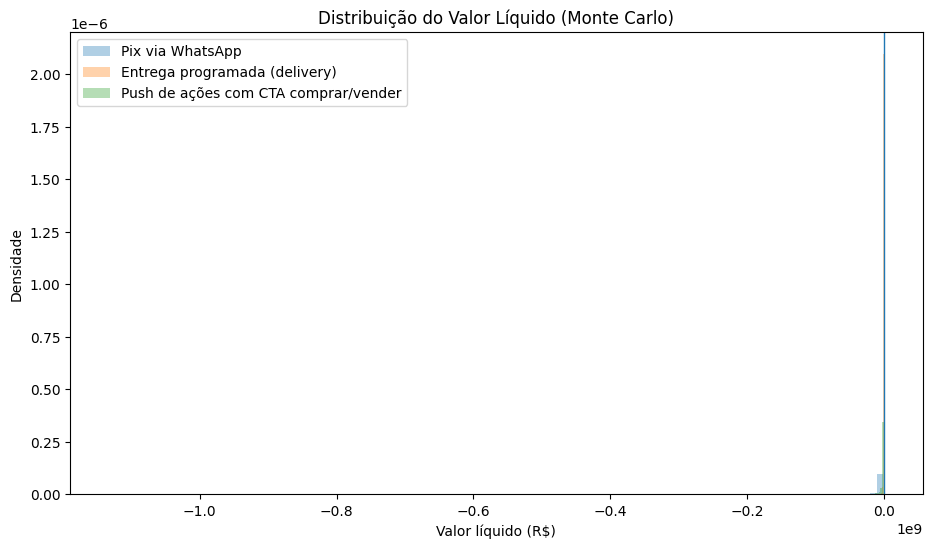

In [11]:
def plot_net_distributions(sims: Dict[str, pd.DataFrame], bins=120):
    plt.figure(figsize=(11,6))
    for name, sim in sims.items():
        net = sim["net_value"].values
        plt.hist(net, bins=bins, alpha=0.35, density=True, label=name)
    plt.axvline(0, linewidth=1)
    plt.title("Distribuição do Valor Líquido (Monte Carlo)")
    plt.xlabel("Valor líquido (R$)")
    plt.ylabel("Densidade")
    plt.legend()
    plt.show()

plot_net_distributions(sims)


## 6) Ranking final (score composto)

Default (ajustável):
- 45% EV
- 25% CVaR (risco de cauda)
- 15% learning
- 10% effort (penaliza)
- 5% risk (penaliza)


In [12]:
def minmax(x):
    x = np.array(x, dtype=float)
    if np.allclose(x.max(), x.min()):
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

rank_df = summary_df.copy()

rank_df["EV_norm"] = minmax(rank_df["EV_mean"])
rank_df["Learn_norm"] = minmax(rank_df["learning_value"])
rank_df["Effort_norm"] = 1 - minmax(rank_df["effort"])
rank_df["Risk_norm"] = 1 - minmax(rank_df["risk"])
rank_df["CVaR_norm"] = minmax(rank_df["CVaR_5%"])

weights = {
    "EV_norm": 0.45,
    "CVaR_norm": 0.25,
    "Learn_norm": 0.15,
    "Effort_norm": 0.10,
    "Risk_norm": 0.05,
}

rank_df["score"] = sum(rank_df[k] * w for k, w in weights.items())
rank_df = rank_df.sort_values("score", ascending=False)

rank_df[[
    "score","EV_mean","P(net>0)","VaR_5%","CVaR_5%","effort","risk","learning_value"
]]


,score,EV_mean,P(net>0),VaR_5%,CVaR_5%,effort,risk,learning_value
name,,,,,,,,
Entrega programada (delivery),0.883333,-7.129959e+05,0.0,-1.682288e+06,-3.137189e+06,6.0,5.0,0.65
Push de ações com CTA comprar/vender,0.540757,-1.882537e+06,0.0,-7.625490e+06,-1.910122e+07,5.5,9.2,0.55
Pix via WhatsApp,0.154762,-4.257101e+06,0.0,-1.644588e+07,-3.917509e+07,8.5,8.8,0.85


## 7) Sensibilidade: o que mais explica o resultado?

Usa correlação Spearman (robusta).


In [13]:
def sensitivity(sim: pd.DataFrame) -> pd.Series:
    cols = ["adoption","lift","value","cost","downside"]
    out = {}
    y = sim["net_value"].rank().values
    for c in cols:
        x = sim[c].rank().values
        out[c] = np.corrcoef(x, y)[0,1]
    return pd.Series(out).sort_values(key=lambda s: s.abs(), ascending=False)

sens = {name: sensitivity(sim) for name, sim in sims.items()}
pd.DataFrame(sens)


,Pix via WhatsApp,Entrega programada (delivery),Push de ações com CTA comprar/vender
adoption,-0.161291,-0.286222,-0.042958
cost,-0.161291,-0.286222,-0.042958
downside,-0.961623,-0.889549,-0.984118
lift,0.004877,0.052910,0.037204
value,-0.066793,-0.066329,0.023813


# 8) (Opcional) Análise causal com DoWhy

Use quando você tem dados históricos (logs) e exposure (treatment) bem definido.


In [ ]:
# Se precisar:
# !pip -q install dowhy


In [14]:
# Exemplo sintético (substitua pelo seu dataset real)
import numpy as np
import pandas as pd

N = 50_000
rng = np.random.default_rng(7)

segment = rng.integers(0, 5, size=N)
engagement = rng.gamma(shape=2.0, scale=2.0, size=N)
tenure = rng.exponential(scale=12, size=N)

p_treat = 1 / (1 + np.exp(-( -1.2 + 0.35*engagement + 0.04*tenure )))
treatment = rng.binomial(1, p_treat)

base = 0.4 + 0.20*engagement + 0.03*tenure
true_ate = 0.8
outcome = base + true_ate*treatment + rng.normal(0, 1.5, size=N)

df = pd.DataFrame({
    "treatment": treatment,
    "outcome": outcome,
    "segment": segment,
    "engagement": engagement,
    "tenure": tenure
})

df.head()


,treatment,outcome,segment,engagement,tenure
0,1,1.744875,4,1.571865,28.615574
1,1,0.608584,3,17.026445,11.469114
2,1,-0.091379,3,0.302055,2.212113
3,0,3.214861,4,1.701713,6.585440
4,1,5.995577,2,2.635620,23.811590


In [16]:
!pip -q install dowhy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [15]:
from dowhy import CausalModel

model = CausalModel(
    data=df,
    treatment="treatment",
    outcome="outcome",
    common_causes=["segment","engagement","tenure"]
)

identified_estimand = model.identify_effect()
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print("Causal Estimate:", estimate.value)


ModuleNotFoundError: No module named 'dowhy'

In [ ]:
refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)
print(refute)
